In [1]:
#Task 1 — Data Loading & Exploration
import pandas as pd

# Load dataset
df = pd.read_csv("Reviews.csv")


# Display first 10 rows
df.head(10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [2]:
#Check how many rows and columns are there
df.shape

(5000, 10)

In [3]:
# #Identify which column contains the review text
df.columns.tolist()
df.dtypes

Id                        int64
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int64
HelpfulnessDenominator    int64
Score                     int64
Time                      int64
Summary                     str
Text                        str
dtype: object

In [4]:
# Task 2 — Data Cleaning
df = df[['Text', 'Score']]

#Remove rows where the review text is empty or null
df = df.dropna(subset=['Text'])

#Remove duplicate reviews
df = df.drop_duplicates(subset=['Text'])

# Reset index
df = df.reset_index(drop=True)

# Check cleaned data
df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [5]:
#Task 3 — Sentiment Analysis

from textblob import TextBlob
import pandas as pd
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


In [6]:
df['Sentiment'] = df['Text'].apply(get_sentiment)

df.head()

,Text,Score,Sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative
2,This is a confection that has been around a fe...,4,Positive
3,If you are looking for the secret ingredient i...,2,Positive
4,Great taffy at a great price. There was a wid...,5,Positive


In [7]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


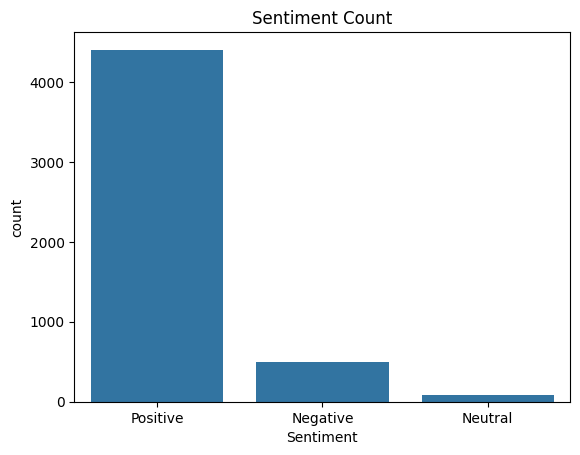

In [8]:
#Task 4 — Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Chart 1: Bar chart showing count of Positive, Negative, and Neutral reviews

sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Count")
plt.savefig("charts/bar_chart.png")
plt.show()

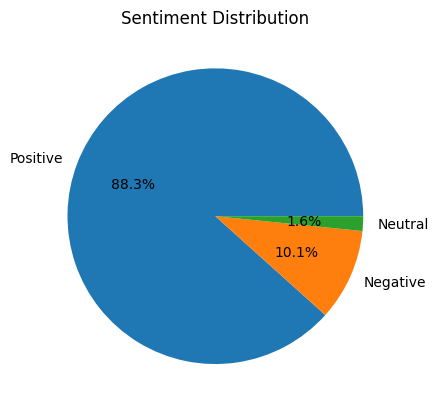

In [9]:
#Chart 2: Pie chart showing the percentage distribution of sentiments
df['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.savefig("charts/pie_chart.png")
plt.show()

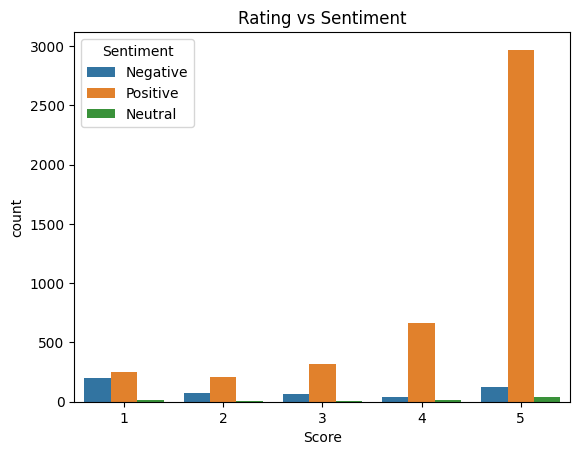

In [10]:
sns.countplot(x='Score', hue='Sentiment', data=df)
plt.title("Rating vs Sentiment")
plt.savefig("charts/chart3_length.png")
plt.show()

In [11]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_reviews['Text'].head(50)

1      Product arrived labeled as Jumbo Salted Peanut...
14     The Strawberry Twizzlers are my guilty pleasur...
49     This oatmeal is not good. Its mushy, soft, I d...
51     This wasn't in stock the last time I looked. I...
61     Arrived in 6 days and were so stale i could no...
66     I purchased the Mango flavor, and to me it doe...
68     this was sooooo deliscious but too bad i ate e...
93     This is the same food we get at pet store. But...
97     My English Bulldog had skin allergies the summ...
98     I fed this to my Golden Retriever and he hated...
128    I LOVE spicy ramen, but for whatever reasons t...
134    I love this flavor of ramen! I don't eat other...
137    I keep trying other brands.... cheaper brands....
152    These singles sell for $2.50 - $3.36 at the st...
158    I've never heard of the SAFCOL brand before bu...
160    I have always purchased Star-Kist tuna but tho...
166    I don't know how long these sat on the back of...
178    Couldn't believe it when

In [12]:
# Task 5 — Insights & Summary

What percentage of reviews are positive?
The sentiment analysis of Amazon product reviews shows that around 88.3% of the reviews are positive, indicating that most customers are satisfied with the products.

What do customers mostly complain about in negative reviews?
Negative reviews mainly highlight issues such as bad taste, stale or low-quality products, and unmet expectations, as verified from the analysis of negative review texts.

What surprised you in the data?
One surprising observation was that some reviews with low ratings (such as 2-star ratings) were still classified as positive by the sentiment analysis model.
This indicates that the TextBlob model does not always perfectly match the actual ratings given by users.
Another interesting finding was that the number of neutral reviews was very low, showing that customers usually express strong and clear opinions rather than neutral feedback.

One recommendation for the business based on your findings
The business should focus on improving product quality and freshness, as many negative reviews mention issues like bad taste and stale products.
Ensuring better quality control and accurate product descriptions can help reduce customer dissatisfaction and increase positive reviews.
    


SyntaxError: invalid syntax (2248957969.py, line 4)

In [ ]:
import os
os.makedirs("SentimentAnalysis_Mahak_Kanwar", exist_ok=True)

In [ ]:
import shutil

shutil.move("analysis.ipynb", "SentimentAnalysis_Mahak_Kanwar/")
shutil.move("Reviews.csv", "SentimentAnalysis_Mahak_Kanwar/")
shutil.move("charts", "SentimentAnalysis_Mahak_Kanwar/")
shutil.move("charts", "SentimentAnalysis_Mahak_Kanwar/")

In [ ]:
pip freeze > requirements.txt